In [106]:
import pandas as pd
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import glob
from pathlib import Path
from tqdm import tqdm
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import mannkendall as mk
from datetime import datetime

# Get the most frequent grid_mapping

In [97]:
datadir = "/home/user/These/cordex_htws_cc3d/Data"
dict_area = {}
for grid_mapping in ['ERA5','Lambert_Conformal','rotated_pole','rotated_latitude_longitude']:
    da_cell_area = xr.open_dataset(join(datadir,'cellarea',f'gridarea_CORDEX_EUR11_{grid_mapping}.nc'),engine='netcdf4').cell_area
    da_mask = xr.open_dataset(join(datadir,'mask',f'mask_Europe_land_only_CORDEX_EUR11_{grid_mapping}.nc'),engine='netcdf4').mask
    area_Europe = (da_cell_area * (da_mask.data==0)).sum().data/1e6 # compute the area of studied part of Europe in km²
    dict_area[grid_mapping] = area_Europe
print(dict_area)


{'ERA5': np.float64(8823401.4079335), 'Lambert_Conformal': np.float64(10228306.970050685), 'rotated_pole': np.float64(9613195.996776782), 'rotated_latitude_longitude': np.float64(9580032.801650574)}


In [98]:
df_htws = pd.read_csv(join(datadir,'df_global_htws.csv'),header=0,index_col=0)
df_htws['Relative spatial extent (%)'] = None
for i in tqdm(df_htws.index):
    area_Europe = dict_area[df_htws.loc[i,'grid_mapping']]
    df_htws.loc[i,'Relative spatial extent (%)'] = round(100*df_htws.loc[i,'Spatial extent']/area_Europe,2)

100%|██████████| 38331/38331 [00:11<00:00, 3214.98it/s]


In [117]:
mapping_df = df_htws.groupby('grid_mapping').apply(lambda x: x['model'])
for mapping in ['ERA5','Lambert_Conformal','rotated_pole','rotated_latitude_longitude']:
    print(f'{mapping}: {len(np.unique(mapping_df[(mapping,)].to_list()))}')

ERA5: 19
Lambert_Conformal: 5
rotated_pole: 40
rotated_latitude_longitude: 27


In [6]:
if False:
    need_to_convert = ['ERA5','Lambert_Conformal','rotated_latitude_longitude'] # TODO Check list after all scripts have run
    mapping_target = 'rotated_pole' # TODO Check this
    read_directory = '/scratchu/tmandonnet/CORDEX'
    write_directory = '/scratchu/tmandonnet/CORDEX/remapped_labels_for_figs'
    target_grid_directory = '/data/tmandonnet/CORDEX/cellarea'
    for grid_mapping in ['ERA5','Lambert_Conformal','rotated_pole','rotated_latitude_longitude']:
        if grid_mapping != mapping_target:
            mapping_model_list = np.unique(df_htws[df_htws['grid_mapping']==grid_mapping]['model'])
            for model in tqdm(mapping_model_list):
                labels_files = glob.glob(join(read_directory,model,'labels*.nc'))
                for file in labels_files:
                    if overwrite == True or Path(file).exists() == False:
                        os.makedirs(join(write_directory,model),exist_ok=True)
                        subprocess.call(f"cdo -remapnn,{join(target_grid_directory,f'gridarea_CORDEX_EUR11_{grid_mapping}.nc')} {file} {join(write_directory,model,file.split('/')[-1])}")
        else: # i.e grid_mapping is mapping_target
            mapping_model_list = np.unique(df_htws[df_htws['grid_mapping']==grid_mapping]['model'])
            for model in tqdm(mapping_model_list):
                labels_files = glob.glob(join(read_directory,model,'labels*.nc'))
                for file in labels_files:
                    if overwrite == True or Path(file).exists() == False:
                        os.makedirs(join(write_directory,model),exist_ok=True)
                        subprocess.call(f"cp {file} {join(write_directory,model,file.split('/')[-1])}")


# Compute years with 92-day-long heatwaves

In [5]:
model_list = np.unique(df_htws['model'])
print(len(model_list))

df_92_days = df_htws[df_htws['Duration']==92]

91


In [6]:
dates_df = pd.DataFrame(index = model_list, columns=['Year of stable 92-day heatwave occurrence','First year of 92-day heatwave'], data=None)
duration_threshold = 92
for model in tqdm(model_list):
    if model in df_92_days['model'].to_list():
        sub_df = df_htws[df_htws['model']==model]
        year = 2099
        period_start = 1975
        while year>=period_start:
            sub_df_year = sub_df[sub_df['Year']==year]
            if sub_df_year['Duration'].max() < duration_threshold:
                break
            year = year - 1
        stable_long_heatwave_year = year + 1 # The first year with consistent occurrence of 92-day-long heatwaves is year+1 if there is no 92-day-long heatwave on year
    
        first_92_heatwave_year=2100
        year = 1975
        period_end = 2099
        while year<=period_end:
            sub_df_year = sub_df[sub_df['Year']==year]
            if sub_df_year['Duration'].max() >= duration_threshold:
                break
            year = year + 1
        first_92_heatwave_year = year # The first year with consistent occurrence of 92-day-long heatwaves is year+1 if there is no 92-day-long heatwave on year

    dates_df.loc[model,'Year of stable 92-day heatwave occurrence'] = stable_long_heatwave_year
    dates_df.loc[model,'First year of 92-day heatwave'] = first_92_heatwave_year

print(f'There are {len(dates_df[dates_df['Year of stable 92-day heatwave occurrence']==2100])} models which never reach a level always showing a {duration_threshold}-day-long heatwave.')
print(f'There are {len(dates_df[dates_df['First year of 92-day heatwave']==2100])} models which never show any {duration_threshold}-day-long heatwave.')

100%|██████████| 91/91 [00:10<00:00,  8.82it/s]

There are 7 models which never reach a level always showing a 92-day-long heatwave.
There are 0 models which never show any 92-day-long heatwave.


In [24]:
dates_df[(dates_df['Year of stable 92-day heatwave occurrence']==2100) | (dates_df['First year of 92-day heatwave']==2100)]

,Year of stable 92-day heatwave occurrence,First year of 92-day heatwave
CLMcom_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CLMcom-CCLM4-8-17_v1_day_tasmax_v20140515,2100,2072
CNRM_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_v2_day_tasmax_v20190828,2100,2041
GERICS_ICHEC-EC-EARTH_rcp45_r12i1p1_GERICS-REMO2015_v1_day_tasmax_v20210128,2100,2031
GERICS_NCC-NorESM1-M_rcp45_r1i1p1_GERICS-REMO2015_v1_day_tasmax_v20200713,2100,2039
IPSL_IPSL-IPSL-CM5A-MR_rcp45_r1i1p1_IPSL-WRF381P_v1_day_tasmax_v20190919,2100,2032
MPI-CSC_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_MPI-CSC-REMO2009_v1_day_tasmax_v20160525,2100,2069
SMHI_IPSL-IPSL-CM5A-MR_rcp45_r1i1p1_SMHI-RCA4_v1_day_tasmax_v20141024,2100,2031


In [26]:
dates_df[(dates_df['Year of stable 92-day heatwave occurrence']==1975) | (dates_df['First year of 92-day heatwave']==1975)]

,Year of stable 92-day heatwave occurrence,First year of 92-day heatwave
CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975
CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_v1_day_tasmax_v20140515,1975,1975
CLMcom_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975
DMI_NCC-NorESM1-M_rcp45_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975
DMI_NCC-NorESM1-M_rcp85_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975
GERICS_NCC-NorESM1-M_rcp45_r1i1p1_GERICS-REMO2015_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975
GERICS_NCC-NorESM1-M_rcp85_r1i1p1_GERICS-REMO2015_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975
KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975
KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975
MOHC_ICHEC-EC-EARTH_rcp85_r12i1p1_MOHC-HadREM3-GA7-05_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,1975,1975


<Axes: >

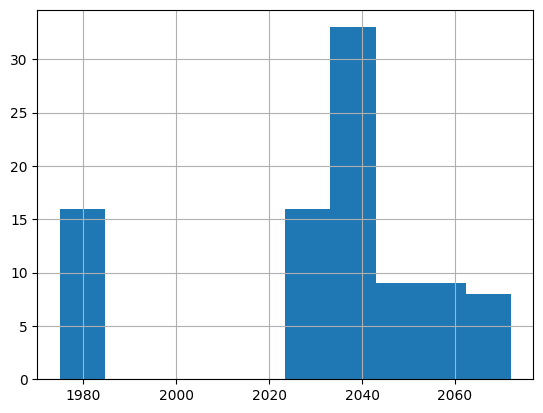

In [27]:
dates_df[dates_df['First year of 92-day heatwave']!=2100]['First year of 92-day heatwave'].hist() # plot years of reaching of consistent occurrence of 92-day-long heatwaves 

<Axes: >

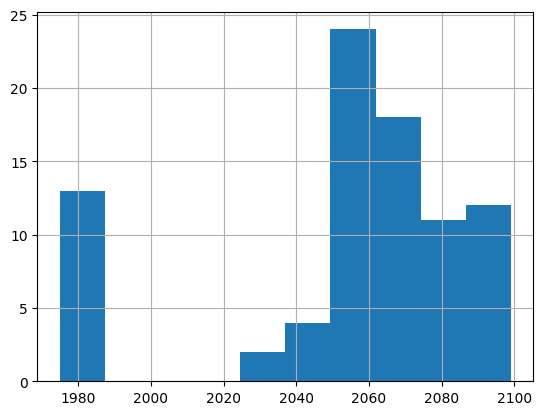

In [28]:
dates_df[dates_df['Year of stable 92-day heatwave occurrence']!=2100]['Year of stable 92-day heatwave occurrence'].hist() # plot years of reaching of consistent occurrence of 92-day-long heatwaves 

In [118]:
df_92_days[['Year','Relative spatial extent (%)']]['Relative spatial extent (%)'].quantile(0.5)

np.float64(4.77)

In [119]:
files_dir = "/home/user/These/cordex_htws_cc3d/Data/output_ERA5"
files_list = np.sort(glob.glob(join(files_dir,'labels*.nc')))

In [109]:
sub_df

,Year,Start Date,End Date,model,original_label,RWL_1,RWL_2,RWL_3,RWL_4,Intensity,...,version_date,calendar,bias-adjusted,grid_mapping,Period RWL 1,Period RWL 2,Period RWL 3,Period RWL 4,Historical,Relative spatial extent (%)
18024,2025,2025-06-09 00:00:00,2025-07-07 00:00:00,ERA5,68,NaN,NaN,NaN,NaN,1.824540,...,before_2005,proleptic_gregorian,False,ERA5,False,False,False,False,True,11.63
18025,2025,2025-07-11 00:00:00,2025-08-05 00:00:00,ERA5,69,NaN,NaN,NaN,NaN,2.069601,...,before_2005,proleptic_gregorian,False,ERA5,False,False,False,False,True,13.77
18027,2025,2025-07-21 00:00:00,2025-08-09 00:00:00,ERA5,71,NaN,NaN,NaN,NaN,1.553559,...,before_2005,proleptic_gregorian,False,ERA5,False,False,False,False,True,5.6


In [112]:
label_list

array([  0, 184, 186, 187, 188, 189])

In [97]:
file.split("/")[-2][-4:]

'ERA5'

In [122]:
df_92_days

,Year,Start Date,End Date,model,original_label,RWL_1,RWL_2,RWL_3,RWL_4,Intensity,...,version_date,calendar,bias-adjusted,grid_mapping,Period RWL 1,Period RWL 2,Period RWL 3,Period RWL 4,Historical,Relative spatial extent (%)
0,NaN,1975-07-05 12:00:00,1975-08-23 12:00:00,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1975,NaN,NaN,NaN,NaN,3.010106,...,v20201215,proleptic_gregorian,False,rotated_pole,False,False,False,False,False,0.05
15,NaN,1981-08-11 12:00:00,1981-08-30 12:00:00,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1981,NaN,NaN,NaN,NaN,1.776026,...,v20201215,proleptic_gregorian,False,rotated_pole,False,False,False,False,False,0.02
19,NaN,1982-07-18 12:00:00,1982-08-07 12:00:00,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1982,NaN,NaN,NaN,NaN,2.296919,...,v20201215,proleptic_gregorian,False,rotated_pole,False,False,False,False,False,0.03
25,NaN,1984-08-01 12:00:00,1984-08-31 12:00:00,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1984,NaN,NaN,NaN,NaN,3.067388,...,v20201215,proleptic_gregorian,False,rotated_pole,False,False,False,False,False,0.05
27,NaN,1986-06-23 12:00:00,1986-07-16 12:00:00,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1986,NaN,NaN,NaN,NaN,2.498400,...,v20201215,proleptic_gregorian,False,rotated_pole,False,False,False,False,False,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38318,NaN,2095-06-01 12:00:00.086400,2095-08-31 12:00:00.086400,CLMcom-ETH_NCC-NorESM1-M_rcp85_r1i1p1_CLMcom-E...,2095,NaN,NaN,NaN,NaN,3.511880,...,v20191210,noleap,False,rotated_pole,False,False,False,False,False,0.1
38320,NaN,2096-06-01 12:00:00.086400,2096-08-31 12:00:00.086400,CLMcom-ETH_NCC-NorESM1-M_rcp85_r1i1p1_CLMcom-E...,2096,NaN,NaN,NaN,NaN,3.473564,...,v20191210,noleap,False,rotated_pole,False,False,False,False,False,0.15
38322,NaN,2097-06-01 12:00:00.086400,2097-08-31 12:00:00.086400,CLMcom-ETH_NCC-NorESM1-M_rcp85_r1i1p1_CLMcom-E...,2097,NaN,NaN,NaN,NaN,3.231792,...,v20191210,noleap,False,rotated_pole,False,False,False,False,False,0.1
38327,NaN,2098-06-01 12:00:00.086400,2098-08-31 12:00:00.086400,CLMcom-ETH_NCC-NorESM1-M_rcp85_r1i1p1_CLMcom-E...,2098,NaN,NaN,NaN,NaN,2.907885,...,v20191210,noleap,False,rotated_pole,False,False,False,False,False,0.13


In [158]:
(df_htws['model'].apply(lambda x: 'Adjust' in x)).sum()

np.int64(4445)

100%|██████████| 51/51 [00:08<00:00,  6.05it/s]


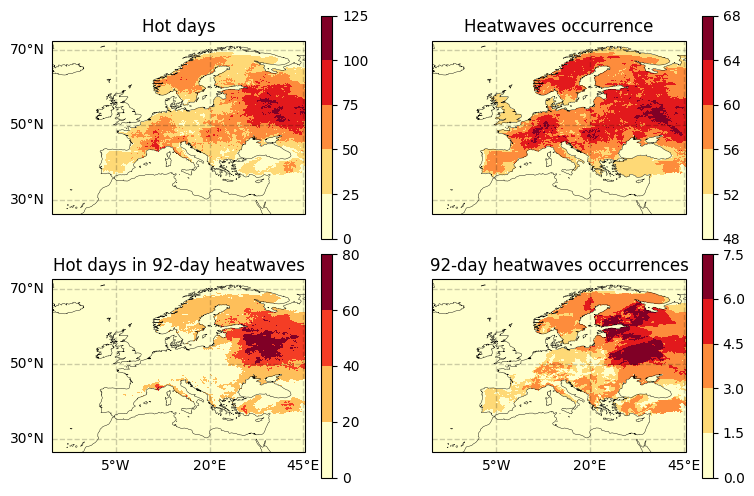

0


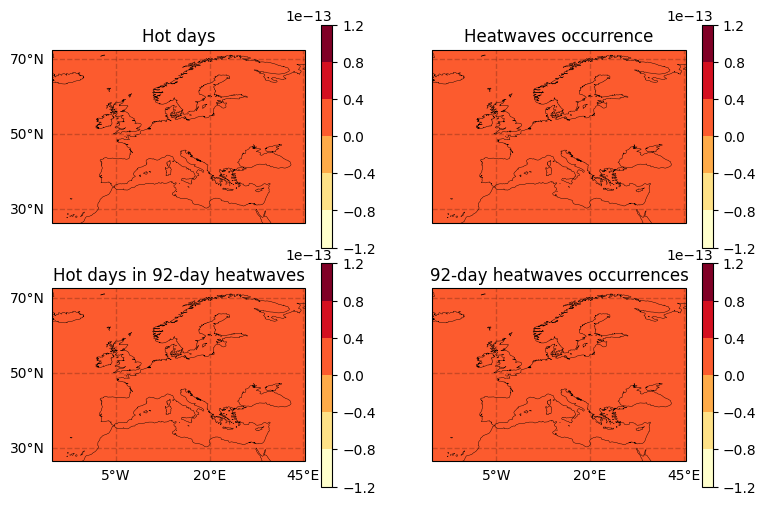

1


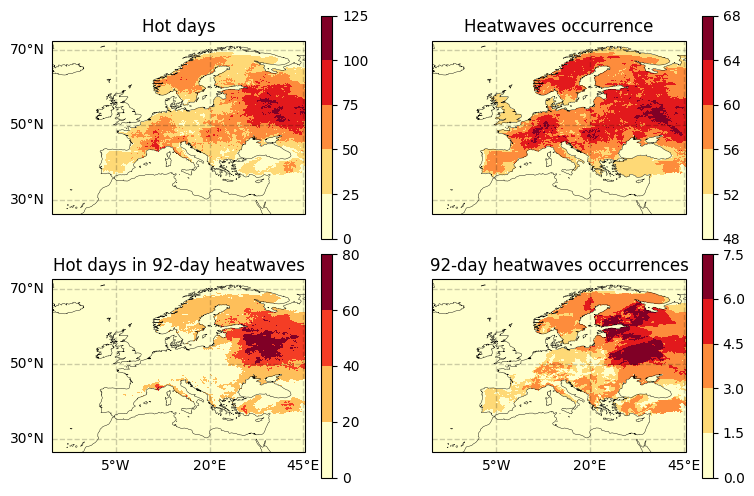

2


In [ ]:
# Plot number of hot days per location
#files_dir = "/scratchu/tmandonnet/CORDEX/remapped_labels_for_figs"
#files_list = np.sort(glob.glob(join(files_dir,'*','labels*.nc')))
files_dir = "/home/user/These/cordex_htws_cc3d/Data/output_ERA5"
files_list = np.sort(glob.glob(join(files_dir,'labels*.nc')))
# Initialize arrays to hold data
labels_days_all = xr.open_dataset(files_list[0],engine='netcdf4').label.copy().sum(dim='time')
labels_days_all.data = np.zeros(np.shape(labels_days_all))
labels_htws_all = labels_days_all.copy()
labels_days_all_92 = labels_days_all.copy()
labels_htws_all_92 = labels_days_all.copy()

labels_days_raw = labels_days_all.copy()
labels_htws_raw = labels_days_all.copy()
labels_days_raw_92 = labels_days_all.copy()
labels_htws_raw_92 = labels_days_all.copy()

labels_days_adj = labels_days_all.copy()
labels_htws_adj = labels_days_all.copy()
labels_days_adj_92 = labels_days_all.copy()
labels_htws_adj_92 = labels_days_all.copy()

#df_92_days = df_htws[df_htws['Duration']==92]
df_92_days = df_htws[df_htws['Duration']>=20]

start_year = 1975
end_year = 2099
# Iterate over files
for file in tqdm(files_list):
    year = int(file[-21:-17])
    model = file.split("/")[-2]
    bias_adjusted = 'Adjust' in model
    if year>= start_year and year <= end_year and model != 'ERA5':
        #sub_df = df_92_days[(df_92_days['model']==model) & (df_92_days['Year']==year)]
        sub_df = df_92_days[(df_92_days['model']==file.split("/")[-2][-4:]) & (df_92_days['Year']==year)]
        file_labels = xr.open_dataset(file,engine='netcdf4').label
        bool_labels = (file_labels>0)
        labels_days_all.data = labels_days_all.data + bool_labels.sum(dim='time').data
        if bias_adjusted:
            labels_days_adj.data = labels_days_adj.data + bool_labels.sum(dim='time').data
        else:
            labels_days_raw.data = labels_days_raw.data + bool_labels.sum(dim='time').data
        labels_list = np.unique(file_labels.data)
        labels_list = labels_list[np.where(labels_list!=0)]
        for lab in labels_list:
            bool_labels = np.max(file_labels==lab,axis=0)
            labels_htws_all.data = labels_htws_all.data + bool_labels.data
            if bias_adjusted:
                labels_htws_adj.data = labels_htws_adj.data + bool_labels.data
            else:
                labels_htws_raw.data = labels_htws_raw.data + bool_labels.data
            if lab in sub_df['original_label'].values:
                labels_htws_all_92.data = labels_htws_all_92.data + bool_labels.data
                labels_days_all_92.data = labels_days_all_92.data + np.sum(file_labels==lab,axis=0)
                if bias_adjusted:
                    labels_htws_adj_92.data = labels_htws_adj_92.data + bool_labels.data
                    labels_days_adj_92.data = labels_days_adj_92.data + np.sum(file_labels==lab,axis=0)
                else:
                    labels_htws_raw_92.data = labels_htws_raw_92.data + bool_labels.data
                    labels_days_raw_92.data = labels_days_raw_92.data + np.sum(file_labels==lab,axis=0)

# Plot figure
labels_list = [
    [[labels_days_all,labels_htws_all],[labels_days_all_92,labels_htws_all_92]],
    [[labels_days_adj,labels_htws_adj],[labels_days_adj_92,labels_htws_adj_92]],
    [[labels_days_raw,labels_htws_raw],[labels_days_raw_92,labels_htws_raw_92]]
]
for count,fig_title in enumerate(['hot_days_4_panels_all_models','hot_days_4_panels_bias_adj_models','hot_days_4_panels_raw_models']):
    proj = ccrs.PlateCarree()
    fig,axes = plt.subplots(
        2, 2, figsize=(9, 6), sharex=True, sharey=True,
        subplot_kw={'projection': proj, "aspect": 1},
        gridspec_kw = {'wspace':0.2, 'hspace':0.07},
    )

    titles_list = [['Hot days','Heatwaves occurrence'],['Hot days in 92-day heatwaves','92-day heatwaves occurrences']]
    
    for i in [0,1]:
        for j in [0,1]:
            ax = axes[i][j]
            labels = labels_list[count][i][j]
            img = labels.plot(cmap='YlOrRd',ax=ax,levels=6,add_labels=False)
            ax.set_title(titles_list[i][j])
            ax.add_feature(cfeature.COASTLINE,linewidth=0.3)
            #ax.add_feature(cfeature.LAND)
            #ax.add_feature(cfeature.OCEAN)
            #ax.add_feature(cfeature.LAKES, alpha=0.5)
            #ax.add_feature(cfeature.RIVERS, alpha=0.5)

            gl = ax.gridlines(crs=proj, linewidth=1, color='black', alpha=0.2, linestyle="--")

            gl.ylocator = mticker.FixedLocator(np.arange(-90,90,20))
            gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 25))

            if i==1:
                gl.bottom_labels = True
            if j==0:
                gl.left_labels = True
    write_directory = '/home/user/These/cordex_htws_cc3d'
    #plt.savefig(join(write_directory,f'{fig_title}.pdf'),dpi=1200)
    plt.show()

100%|██████████| 130/130 [01:13<00:00,  1.76it/s]


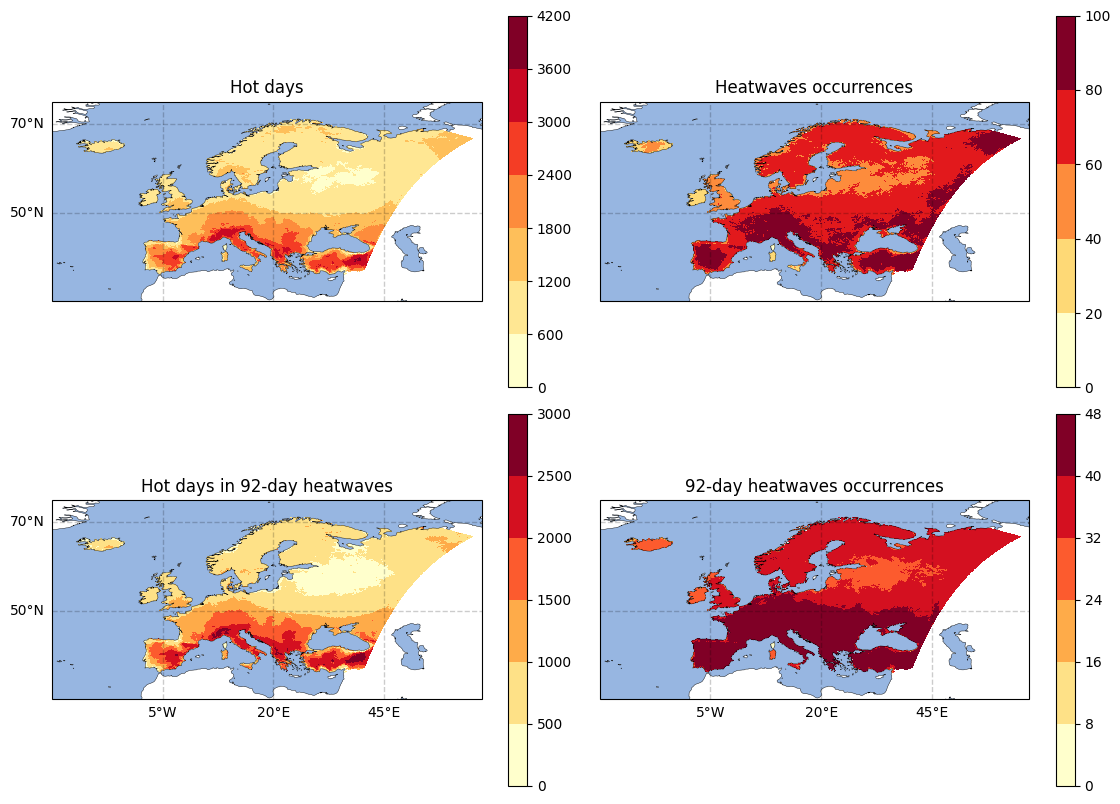

In [90]:
# Plot number of hot days per location
#files_dir = "/scratchu/tmandonnet/CORDEX/remapped_labels_for_figs"
#files_list = np.sort(glob.glob(join(files_dir,'*','labels*.nc')))
files_dir = "/home/user/These/cordex_htws_cc3d/Data/CLMcom_CCCma-CanESM2_rcp85_r1i1p1_CLMcom-CCLM4-8-17_v1_day_tasmax_v20171121"
files_list = np.sort(glob.glob(join(files_dir,'labels*.nc')))
# Initialize arrays to hold data
labels_days_all = xr.open_dataset(files_list[0],engine='netcdf4').label.copy().sum(dim='time')
labels_days_all.data = np.zeros(np.shape(labels_days_all))
labels_htws_all = labels_days_all.copy()
labels_days_all_92 = labels_days_all.copy()
labels_htws_all_92 = labels_days_all.copy()

labels_days_raw = labels_days_all.copy()
labels_htws_raw = labels_days_all.copy()
labels_days_raw_92 = labels_days_all.copy()
labels_htws_raw_92 = labels_days_all.copy()

labels_days_adj = labels_days_all.copy()
labels_htws_adj = labels_days_all.copy()
labels_days_adj_92 = labels_days_all.copy()
labels_htws_adj_92 = labels_days_all.copy()

df_htws = pd.read_csv(join(files_dir,'df_htws.csv'),header=0,index_col=0)
df_92_days = df_htws[df_htws['Duration']==92]

start_year = 1975
end_year = 2099
# Iterate over files
for file in tqdm(files_list):
    year = int(file[-21:-17])
    model = file.split("/")[-2]
    bias_adjusted = 'Adjust' in model
    if True:
        #sub_df = df_92_days[(df_92_days['model']==model) & (df_92_days['Year']==year)]
        sub_df = df_92_days[df_92_days['Year']==year]
        file_labels = xr.open_dataset(file,engine='netcdf4').label
        bool_labels = (file_labels>0)
        labels_days_all.data = labels_days_all.data + bool_labels.sum(dim='time').data
        if bias_adjusted:
            labels_days_adj.data = labels_days_adj.data + bool_labels.sum(dim='time').data
        else:
            labels_days_raw.data = labels_days_raw.data + bool_labels.sum(dim='time').data
        labels_list = np.unique(file_labels.data)
        labels_list = labels_list[np.where(labels_list!=0)]
        for lab in labels_list:
            bool_labels = np.max(file_labels==lab,axis=0)
            labels_htws_all.data = labels_htws_all.data + bool_labels.data
            if bias_adjusted:
                labels_htws_adj.data = labels_htws_adj.data + bool_labels.data
            else:
                labels_htws_raw.data = labels_htws_raw.data + bool_labels.data
            if lab in sub_df.index.values:
                labels_htws_all_92.data = labels_htws_all_92.data + bool_labels.data
                labels_days_all_92.data = labels_days_all_92.data + np.sum(file_labels==lab,axis=0)
                if bias_adjusted:
                    labels_htws_adj_92.data = labels_htws_adj_92.data + bool_labels.data
                    labels_days_adj_92.data = labels_days_adj_92.data + np.sum(file_labels==lab,axis=0)
                else:
                    labels_htws_raw_92.data = labels_htws_raw_92.data + bool_labels.data
                    labels_days_raw_92.data = labels_days_raw_92.data + np.sum(file_labels==lab,axis=0)

# Plot figure
labels_list = [
    [[labels_days_all,labels_htws_all],[labels_days_all_92,labels_htws_all_92]],
    [[labels_days_adj,labels_htws_adj],[labels_days_adj_92,labels_htws_adj_92]],
    [[labels_days_raw,labels_htws_raw],[labels_days_raw_92,labels_htws_raw_92]]
]

for count,fig_title in enumerate(['hot_days_4_panels_all_models']):#,'hot_days_4_panels_bias_adj_models','hot_days_4_panels_raw_models']):
    proj_pc = ccrs.PlateCarree()
    proj_rp = ccrs.RotatedPole(pole_latitude=39.25, pole_longitude=198)
    fig,axes = plt.subplots(
        2, 2, figsize=(14,10), sharex=True, sharey=True,
        subplot_kw={'projection': proj_pc, "aspect": 1},
        gridspec_kw = {'wspace':0.02, 'hspace':0.07},
    )

    titles_list = [['Hot days','Heatwaves occurrences'],['Hot days in 92-day heatwaves','92-day heatwaves occurrences']]
    
    for i in [0,1]:
        for j in [0,1]:
            ax = axes[i][j]
            labels = labels_list[count][i][j]
            labels = labels.where(labels>0)

            img = labels.plot(cmap='YlOrRd',ax=ax,levels=7,add_labels=False,transform=proj_rp)
            ax.set_extent([-30, 67, 30, 75], crs=proj_pc)
            ax.set_title(titles_list[i][j])
            ax.add_feature(cfeature.COASTLINE,linewidth=0.3)
            #ax.add_feature(cfeature.LAND)
            ax.add_feature(cfeature.OCEAN)

            #ax.contourf(labels.rlon, labels.rlat, labels.data, levels=7, cmap='YlOrRd', transform=proj_rp)

            gl = ax.gridlines(crs=proj_pc, linewidth=1, color='black', alpha=0.2, linestyle="--")

            gl.ylocator = mticker.FixedLocator(np.arange(-90,90,20))
            gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 25))

            if i==1:
                gl.bottom_labels = True
            if j==0:
                gl.left_labels = True
    write_directory = '/home/user/These/cordex_htws_cc3d'
    #plt.savefig(join(write_directory,f'{fig_title}.pdf'),dpi=1200)
    plt.show()

# Compute trends

In [99]:
df_htws = pd.read_csv(join(datadir,'df_global_htws.csv'),header=0,index_col=0)
model_list = np.unique(df_htws['model'])

In [100]:
# Merge GHS and FPOP to form a complete column, for each SSP

df_htws['Exposed_population_ssp1_all_period'] = None
df_htws['HWMId_pop_ssp1_all_period'] = None
df_htws['Exposed_population_ssp2_all_period'] = None
df_htws['HWMId_pop_ssp2_all_period'] = None
df_htws['Exposed_population_ssp3_all_period'] = None
df_htws['HWMId_pop_ssp3_all_period'] = None
df_htws['Exposed_population_ssp4_all_period'] = None
df_htws['HWMId_pop_ssp4_all_period'] = None
df_htws['Exposed_population_ssp5_all_period'] = None
df_htws['HWMId_pop_ssp5_all_period'] = None

split_year_population = 2025
for i in tqdm(df_htws.index):
    year = df_htws.loc[i,'Year']
    for ssp in range (1,6):
        if year <= split_year_population:
            df_htws.loc[i,f'Exposed_population_ssp{ssp}_all_period'] = df_htws.loc[i,f'Exposed_population_ghs']
            df_htws.loc[i,f'HWMId_pop_ssp{ssp}_all_period'] = df_htws.loc[i,f'HWMId_pop_ghs']
        else:
            df_htws.loc[i,f'Exposed_population_ssp{ssp}_all_period'] = df_htws.loc[i,f'Exposed_population_ssp{ssp}']
            df_htws.loc[i,f'HWMId_pop_ssp{ssp}_all_period'] = df_htws.loc[i,f'HWMId_pop_ssp{ssp}']


  0%|          | 0/38331 [00:00<?, ?it/s]

100%|██████████| 38331/38331 [01:29<00:00, 427.24it/s]


In [48]:
df_htws[(df_htws['model']=='CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom-ETH-COSMO-crCLIM-v1-1_v1_day_tasmax_v20200609') & (df_htws['Year']==2020)]

,Year,Start Date,End Date,model,original_label,RWL_1,RWL_2,RWL_3,RWL_4,Intensity,...,Exposed_population_ssp1_all_period,HWMId_pop_ssp1_all_period,Exposed_population_ssp2_all_period,HWMId_pop_ssp2_all_period,Exposed_population_ssp3_all_period,HWMId_pop_ssp3_all_period,Exposed_population_ssp4_all_period,HWMId_pop_ssp4_all_period,Exposed_population_ssp5_all_period,HWMId_pop_ssp5_all_period
151,2020,2020-06-04 12:00:00,2020-06-14 12:00:00,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,151,NaN,NaN,NaN,NaN,2.391803,...,46229159.440647,938800.713294,46229159.440647,938800.713294,46229159.440647,938800.713294,46229159.440647,938800.713294,46229159.440647,938800.713294
152,2020,2020-06-24 12:00:00,2020-07-01 12:00:00,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,152,NaN,NaN,NaN,NaN,2.998664,...,24938798.984692,6033307.432467,24938798.984692,6033307.432467,24938798.984692,6033307.432467,24938798.984692,6033307.432467,24938798.984692,6033307.432467
153,2020,2020-07-04 12:00:00,2020-07-10 12:00:00,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,153,NaN,NaN,NaN,NaN,1.258557,...,16908389.663938,1088291.476391,16908389.663938,1088291.476391,16908389.663938,1088291.476391,16908389.663938,1088291.476391,16908389.663938,1088291.476391


In [101]:
df_frequency = pd.DataFrame(columns=['model','Year','Frequency'],data=None)
count_index=0
for model in tqdm(model_list):
    for year in range(1975,2100):
        df_frequency.loc[count_index,'model'] = model
        df_frequency.loc[count_index,'Year'] = year
        df_frequency.loc[count_index,'Frequency'] = len(df_htws[(df_htws['model']==model) & (df_htws['Year']==year)])
        count_index += 1

100%|██████████| 91/91 [00:31<00:00,  2.90it/s]


In [102]:
df_frequency

,model,Year,Frequency
0,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1975,3
1,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1976,4
2,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1977,2
3,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1978,1
4,CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom...,1979,1
...,...,...,...
11370,UHOH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_UHOH-WRF361...,2095,1
11371,UHOH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_UHOH-WRF361...,2096,1
11372,UHOH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_UHOH-WRF361...,2097,1
11373,UHOH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_UHOH-WRF361...,2098,2


In [103]:
iterables = [
    ['Frequency','Intensity','Spatial extent','Duration','Max','HWMId_sum','Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period',
    'Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period','Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period',
    'Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period'],
    ["p", "ss", "slope", "ucl", "lcl"]
    ]

df_mk = pd.DataFrame(index=model_list,columns=pd.MultiIndex.from_product(iterables, names=["index", "mk"]),dtype=float)

In [109]:
df_mk

index                                              Frequency                  \
mk                                                         p    ss     slope   
CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom-...  0.269421   0.0 -0.004554   
CLMcom-ETH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom...  0.939183   0.0  0.000000   
CLMcom-ETH_NCC-NorESM1-M_rcp85_r1i1p1_CLMcom-ET...  0.628556   0.0 -0.002856   
CLMcom_CCCma-CanESM2_rcp85_r1i1p1_CLMcom-CCLM4-...  0.006883  95.0 -0.015957   
CLMcom_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CLMco...  0.000221  95.0  0.024408   
...                                                      ...   ...       ...   
SMHI_NCC-NorESM1-M_rcp45_r1i1p1_SMHI-RCA4_v1_da...  0.533462   0.0 -0.003164   
SMHI_NCC-NorESM1-M_rcp85_r1i1p1_SMHI-RCA4_v1_da...  0.004000  95.0 -0.013032   
UHOH_ICHEC-EC-EARTH_rcp85_r12i1p1_UHOH-WRF361H_...  0.735256   0.0 -0.000529   
UHOH_MOHC-HadGEM2-ES_rcp85_r1i1p1_UHOH-WRF361H_...  0.276619   0.0 -0.005162   
UHOH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_UHOH-WRF361H...  0.857885   0.0  0.000000   

index                                                                   \
mk                                                       ucl       lcl   
CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom-...  0.001910 -0.014136   
CLMcom-ETH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom...  0.010044 -0.012127   
CLMcom-ETH_NCC-NorESM1-M_rcp85_r1i1p1_CLMcom-ET...  0.007379 -0.012622   
CLMcom_CCCma-CanESM2_rcp85_r1i1p1_CLMcom-CCLM4-... -0.004321 -0.027068   
CLMcom_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CLMco...  0.036142  0.012656   
...                                                      ...       ...   
SMHI_NCC-NorESM1-M_rcp45_r1i1p1_SMHI-RCA4_v1_da...  0.004411 -0.012149   
SMHI_NCC-NorESM1-M_rcp85_r1i1p1_SMHI-RCA4_v1_da... -0.004118 -0.021536   
UHOH_ICHEC-EC-EARTH_rcp85_r12i1p1_UHOH-WRF361H_...  0.007535 -0.011963   
UHOH_MOHC-HadGEM2-ES_rcp85_r1i1p1_UHOH-WRF361H_...  0.001960 -0.016557   
UHOH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_UHOH-WRF361H...  0.008369 -0.010588   

index                                              Intensity                \
mk                                                         p  ss slope ucl   
CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom-...       NaN NaN   NaN NaN   
CLMcom-ETH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom...       NaN NaN   NaN NaN   
CLMcom-ETH_NCC-NorESM1-M_rcp85_r1i1p1_CLMcom-ET...       NaN NaN   NaN NaN   
CLMcom_CCCma-CanESM2_rcp85_r1i1p1_CLMcom-CCLM4-...       NaN NaN   NaN NaN   
CLMcom_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CLMco...       NaN NaN   NaN NaN   
...                                                      ...  ..   ...  ..   
SMHI_NCC-NorESM1-M_rcp45_r1i1p1_SMHI-RCA4_v1_da...       NaN NaN   NaN NaN   
SMHI_NCC-NorESM1-M_rcp85_r1i1p1_SMHI-RCA4_v1_da...       NaN NaN   NaN NaN   
UHOH_ICHEC-EC-EARTH_rcp85_r12i1p1_UHOH-WRF361H_...       NaN NaN   NaN NaN   
UHOH_MOHC-HadGEM2-ES_rcp85_r1i1p1_UHOH-WRF361H_...       NaN NaN   NaN NaN   
UHOH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_UHOH-WRF361H...       NaN NaN   NaN NaN   

index                                                   ...  \
mk                                                 lcl  ...   
CLMcom-ETH_ICHEC-EC-EARTH_rcp85_r12i1p1_CLMcom-... NaN  ...   
CLMcom-ETH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom... NaN  ...   
CLMcom-ETH_NCC-NorESM1-M_rcp85_r1i1p1_CLMcom-ET... NaN  ...   
CLMcom_CCCma-CanESM2_rcp85_r1i1p1_CLMcom-CCLM4-... NaN  ...   
CLMcom_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CLMco... NaN  ...   
...                                                 ..  ...   
SMHI_NCC-NorESM1-M_rcp45_r1i1p1_SMHI-RCA4_v1_da... NaN  ...   
SMHI_NCC-NorESM1-M_rcp85_r1i1p1_SMHI-RCA4_v1_da... NaN  ...   
UHOH_ICHEC-EC-EARTH_rcp85_r12i1p1_UHOH-WRF361H_... NaN  ...   
UHOH_MOHC-HadGEM2-ES_rcp85_r1i1p1_UHOH-WRF361H_... NaN  ...   
UHOH_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_UHOH-WRF361H... NaN  ...   

index                                              Exposed_population_ssp5_all_period  \
mk                                                                      

In [108]:
# Compute MK trend test for frequency
for model in tqdm(df_mk.index):
    sub_df = df_frequency[df_frequency['model']==model]
    dates_array = np.array([datetime(i,1,1) for i in sub_df['Year'].values]) # Convert Year to proper datetime
    observations_array = np.array(sub_df['Frequency']).astype(float)
    mk_result = mk.mk_temp_aggr(dates_array,observations_array,resolution=0.9)
    mk_result = mk_result[list(mk_result.keys())[-1]] # Only take last dict
    df_mk.loc[model,('Frequency','p')] = mk_result['p']
    df_mk.loc[model,('Frequency','ss')] = mk_result['ss']
    df_mk.loc[model,('Frequency','slope')] = mk_result['slope']
    df_mk.loc[model,('Frequency','lcl')] = mk_result['lcl']
    df_mk.loc[model,('Frequency','ucl')] = mk_result['ucl']


  4%|▍         | 4/91 [00:01<00:35,  2.48it/s]/home/user/These/cordex_htws_cc3d/.cordex_env/lib/python3.13/site-packages/mannkendall/mk_white.py:94: UserWarning: No statistically significant autocorrelation.
  warnings.warn('No statistically significant autocorrelation.')
100%|██████████| 91/91 [00:33<00:00,  2.70it/s]


In [ ]:
index_list = ['Frequency','Intensity','Spatial extent','Duration','Max','HWMId_sum','Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period',
    'Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period','Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period',
    'Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period']
index_memory_coeff = {'Frequency':1,'Intensity':1,'Spatial extent':1e3,'Duration':1,'Max':1,'HWMId_sum':1e6,'Exposed_population_ssp1_all_period':1e6,'HWMId_pop_ssp1_all_period':1e6,
    'Exposed_population_ssp2_all_period':1e6,'HWMId_pop_ssp2_all_period':1e6,'Exposed_population_ssp3_all_period':1e6,'HWMId_pop_ssp3_all_period':1e6,
    'Exposed_population_ssp4_all_period':1e6,'HWMId_pop_ssp4_all_period':1e6,'Exposed_population_ssp5_all_period':1e6,'HWMId_pop_ssp5_all_period':1e6}
for model in tqdm(df_mk.index):
    sub_df = df_htws[df_htws['model']==model]
    for index in index_list[1:]:
        sub_df[index] = sub_df[index]/index_memory_coeff[index] # Divide to reduce memory load
        dates_array = np.array([datetime(i,1,1) for i in sub_df['Year'].values]) # Convert Year to proper datetime
        observations_array = np.array(sub_df[index]).astype(float)
        mk_result = mk.mk_temp_aggr(dates_array,observations_array,resolution=0.9)
        mk_result = mk_result[list(mk_result.keys())[-1]] # Only take last dict
        df_mk.loc[model,(index,'p')] = mk_result['p']
        df_mk.loc[model,(index,'ss')] = mk_result['ss']
        df_mk.loc[model,(index,'slope')] = mk_result['slope']*index_memory_coeff[index] # Multiply to get correct value
        df_mk.loc[model,(index,'lcl')] = mk_result['lcl']*index_memory_coeff[index] # Multiply to get correct value
        df_mk.loc[model,(index,'ucl')] = mk_result['ucl']*index_memory_coeff[index] # Multiply to get correct value
write_directory = '/home/user/These/cordex_htws_cc3d/Data'
df_mk.to_csv(join(write_directory,'df_mk_trends.csv'))

In [ ]:
df_htws['Spatial extent'] = df_htws['Spatial extent']/1e3 # Divide to reduce memory load
df_htws['HWMId_pop'] = df_htws['HWMId_pop']/1e6 # Divide to reduce memory load
df_htws['HWMId_sum'] = df_htws['HWMId_sum']/1e5 # Divide to reduce memory load
df_htws['Exposed_population'] = df_htws['Exposed_population']/1e6 # Divide to reduce memory load

# Compute MK trend test for all other indices
for index in tqdm(['Intensity','Spatial extent','Duration','Max','HWMId_sum','Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period',
'Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period','Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period',
'Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period','Exposed_population (relative)']):
    dates_array = np.array([datetime(i,1,1) for i in df_htws['Year']]) # Convert Year to proper datetime
    observations_array = np.array(df_htws[index]).astype(float)
    mk_result = mk.mk_temp_aggr(dates_array,observations_array,resolution=0.01)
    mk_result = mk_result[list(mk_result.keys())[-1]] # Only take last dict
    mk_result['_row'] = index
    # If divided to reduce memory load, set back to original value
    if index == 'Spatial extent':
        mk_result['ucl'] = mk_result['ucl']*1e3
        mk_result['lcl'] = mk_result['lcl']*1e3
        mk_result['slope'] = mk_result['slope']*1e3
    elif index == 'HWMId_pop':
        mk_result['ucl'] = mk_result['ucl']*1e6
        mk_result['lcl'] = mk_result['lcl']*1e6
        mk_result['slope'] = mk_result['slope']*1e6
    elif index == 'HWMId_sum':
        mk_result['ucl'] = mk_result['ucl']*1e5
        mk_result['lcl'] = mk_result['lcl']*1e5
        mk_result['slope'] = mk_result['slope']*1e5
    elif index == 'Exposed_population':
        mk_result['ucl'] = mk_result['ucl']*1e6
        mk_result['lcl'] = mk_result['lcl']*1e6
        mk_result['slope'] = mk_result['slope']*1e6
    mk_result_dict_list.append(mk_result)

df_htws['Spatial extent'] = df_htws['Spatial extent']*1e3 # Set back to original value
df_htws['HWMId_pop'] = df_htws['HWMId_pop']*1e6 # Set back to original value
df_htws['HWMId_sum'] = df_htws['HWMId_sum']*1e5 # Set back to original value
df_htws['Exposed_population'] = df_htws['Exposed_population']*1e6 # Divide to reduce memory load

# Export mk_result to JSON file
mk_result_json = json.dumps(mk_result_dict_list)
with open(join(write_directory,"mk_result.json"),'w') as f:
    f.write(mk_result_json)

# Export frequency to csv
df_frequency.rename_axis(index="Year").to_csv(join(write_directory,"frequency.csv"))

df_best_scores = pd.read_csv(join(read_directory,f"summary_detection_overlap_sensitivity.csv"),header=0, index_col=0)

df_scores = df_scores.loc[["Intensity","HWMId_sum","Exposed_population","HWMId_pop"]]

get_index = df_best_scores[(df_best_scores['temp_variable']==temp_variable)&(df_best_scores['daily_var']==daily_var)&(df_best_scores['start_year']==start_year)&(df_best_scores['end_year']==end_year)&(df_best_scores['start_year_ref']==start_year_ref)&(df_best_scores['end_year_ref']==end_year_ref)&(df_best_scores['anomaly']==anomaly)&(df_best_scores['nb_days']==nb_days)&(df_best_scores['relative_threshold']==relative_threshold)&(df_best_scores['threshold_value']==threshold_value)&(df_best_scores['flex_time_span']==flex_time_span)&(df_best_scores['connectivity']==connectivity)].index.values[0]

# Write MK results into df_best_scores
df_mk_result = pd.json_normalize(mk_result_dict_list)
df_mk_result = df_mk_result.set_index('_row')